In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import skimage
#import scvelo as scv
#import loompy as lmp
#import pooch
from anndata import AnnData
from scipy import io
from scipy.stats import median_abs_deviation
from scipy.sparse import coo_matrix, csr_matrix

In [3]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor = "white")
%matplotlib inline

In [66]:
# Get the current working directory
cwd = os.getcwd()
# Print the current working directory
print("Current working directory: {0}".format(cwd))
qc_file = "ctnnd2_scrnaseq_qc.h5ad"
results_file = "ctnnd2_scrnaseq_clusters.h5ad"  # the file that will store the analysis results
filtered_raw = "ctnnd2_scrnaseq_filtered_raw.h5ad" # the file that will store QC-filtered data before normalization

Current working directory: C:\Users\Gabrielle\Documents\GitHub\ctnnd2_scrnaseq_analysis\cleaned_scripts


In [7]:
adata_KO2 = sc.read_10x_mtx(
    "Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 3/snRNAseq_dataset/GEO_submission/processed_data/filtered_matrices/KO2_filtered", # the directory with the `.mtx` file
    var_names="gene_symbols", # use gene symbols for the variable names (variables-axis index)
    cache=True, # write a cache file for faster subsequent reading
)
adata_KO2.var_names_make_unique()

adata_KO3 = sc.read_10x_mtx(
    "Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 3/snRNAseq_dataset/GEO_submission/processed_data/filtered_matrices/KO3_filtered", # the directory with the `.mtx` file
    var_names="gene_symbols", # use gene symbols for the variable names (variables-axis index)
    cache=True, # write a cache file for faster subsequent reading
)
adata_KO3.var_names_make_unique()

adata_KO4 = sc.read_10x_mtx(
    "Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 3/snRNAseq_dataset/GEO_submission/processed_data/filtered_matrices/KO4_filtered", # the directory with the `.mtx` file
    var_names="gene_symbols", # use gene symbols for the variable names (variables-axis index)
    cache=True, # write a cache file for faster subsequent reading
)
adata_KO4.var_names_make_unique()

adata_WT2 = sc.read_10x_mtx(
    "Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 3/snRNAseq_dataset/GEO_submission/processed_data/filtered_matrices/WT2_filtered", # the directory with the `.mtx` file
    var_names="gene_symbols", # use gene symbols for the variable names (variables-axis index)
    cache=True, # write a cache file for faster subsequent reading
)
adata_WT2.var_names_make_unique()

adata_WT3 = sc.read_10x_mtx(
    "Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 3/snRNAseq_dataset/GEO_submission/processed_data/filtered_matrices/WT3_filtered", # the directory with the `.mtx` file
    var_names="gene_symbols", # use gene symbols for the variable names (variables-axis index)
    cache=True, # write a cache file for faster subsequent reading
)
adata_WT3.var_names_make_unique()

adata_WT4 = sc.read_10x_mtx(
    "Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 3/snRNAseq_dataset/GEO_submission/processed_data/filtered_matrices/WT4_filtered", # the directory with the `.mtx` file
    var_names="gene_symbols", # use gene symbols for the variable names (variables-axis index)
    cache=True, # write a cache file for faster subsequent reading
)
adata_WT4.var_names_make_unique()

... writing an h5ad cache file to speedup reading next time
... writing an h5ad cache file to speedup reading next time
... writing an h5ad cache file to speedup reading next time
... writing an h5ad cache file to speedup reading next time
... writing an h5ad cache file to speedup reading next time
... writing an h5ad cache file to speedup reading next time


In [18]:
# add some metadata
adata_KO2.obs['condition']="KO"
adata_KO2.obs['sample']="KO2"

adata_KO3.obs['condition']="KO"
adata_KO3.obs['sample']="KO3"

adata_KO4.obs['condition']="KO"
adata_KO4.obs['sample']="KO4"

adata_WT2.obs['condition']="WT"
adata_WT2.obs['sample']="WT2"

adata_WT3.obs['condition']="WT"
adata_WT3.obs['sample']="WT3"

adata_WT4.obs['condition']="WT"
adata_WT4.obs['sample']="WT4"

# merge into one object.
adata = adata_KO2.concatenate(adata_KO3, adata_KO4, adata_WT2, adata_WT3, adata_WT4)

# and delete individual datasets to save space
del(adata_KO2, adata_KO3, adata_KO4)
del(adata_WT2, adata_WT3, adata_WT4)

C:\Users\Gabrielle\AppData\Local\Temp\ipykernel_43556\1609101963.py:21: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_KO2.concatenate(adata_KO3, adata_KO4, adata_WT2, adata_WT3, adata_WT4)


In [19]:
# pre-filtering counts:
print(adata.obs["sample"].value_counts())

sample
WT4    25360
WT2    20164
KO4    19380
KO3    17441
WT3    16092
KO2    11268
Name: count, dtype: int64


normalizing counts per cell
    finished (0:00:00)


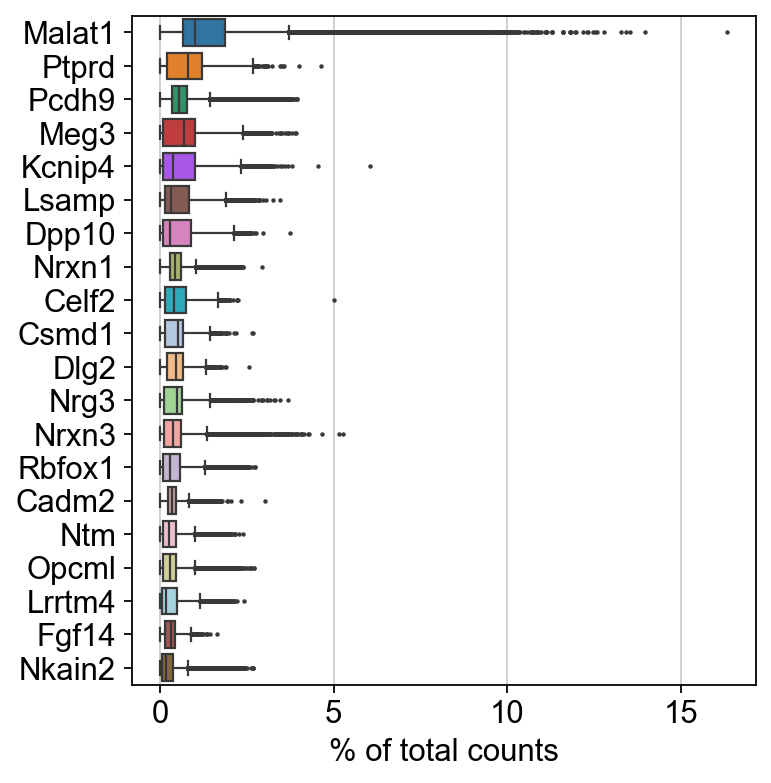

In [20]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [21]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("mt-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^Hb[^(P)]")

#calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 109705 × 32227
    obs: 'condition', 'sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

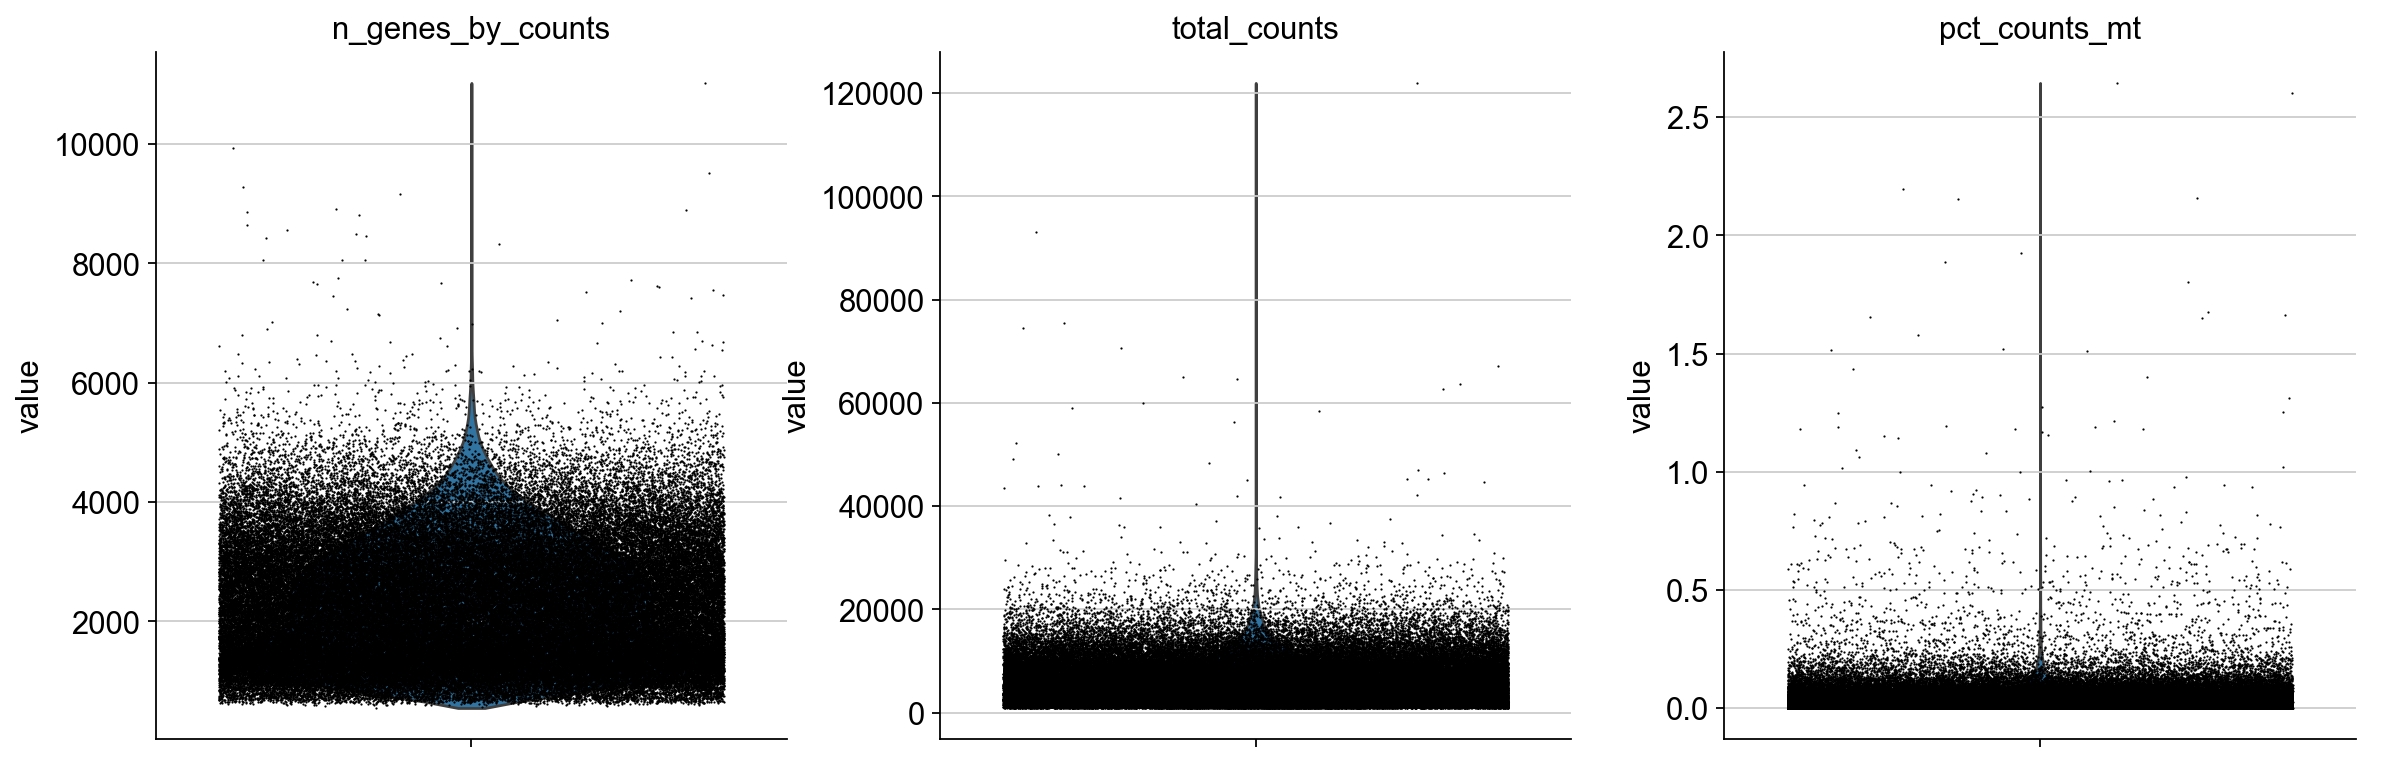

In [22]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
            jitter=0.4, multi_panel=True)

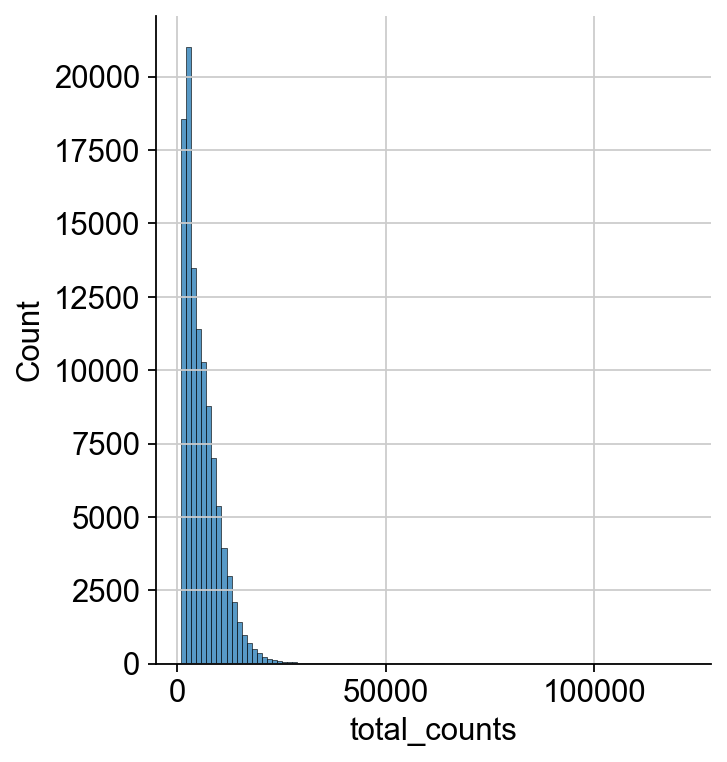

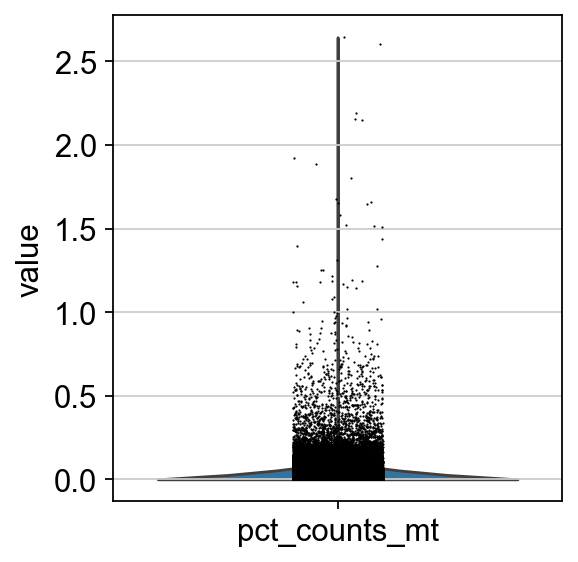

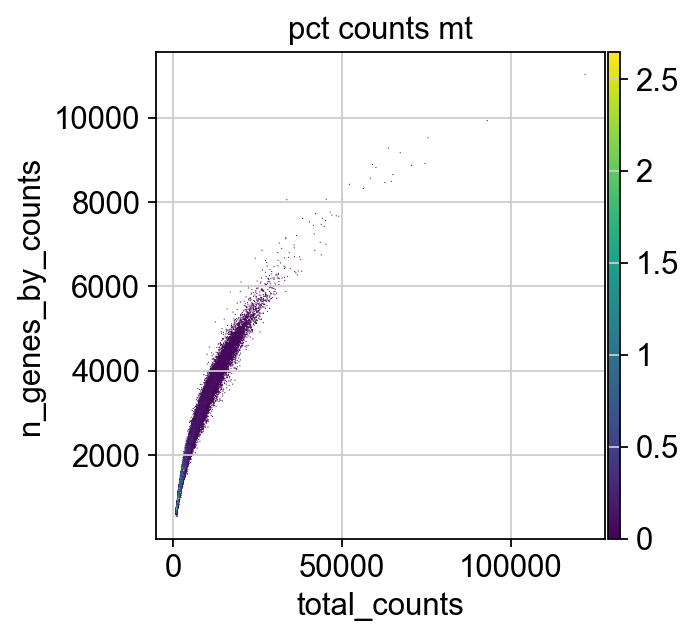

In [23]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [24]:
#QC with automatiuc thresholding and filtering based on median absolute deviations (MAD)
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

#appy function to gene and cell counts with threshold of 5 MADs
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
print(adata.obs.outlier.value_counts())

#Filter mitochondrial counts with thresholds of 3 MADs and 8% mitochondrial counts
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
print(adata.obs.mt_outlier.value_counts())

outlier
False    106800
True       2905
Name: count, dtype: int64
mt_outlier
False    102458
True       7247
Name: count, dtype: int64


In [27]:
#filter based on cell counts, gene counts, and mt gene expression
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 109705
Number of cells after filtering of low quality cells: 99966


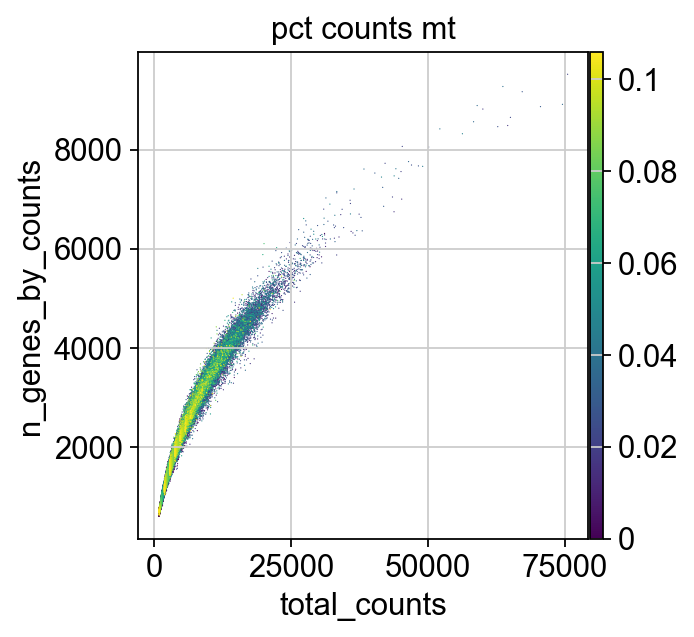

In [28]:
#Check for cells that have too many mitochondrial genes expressed or too many total counts:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

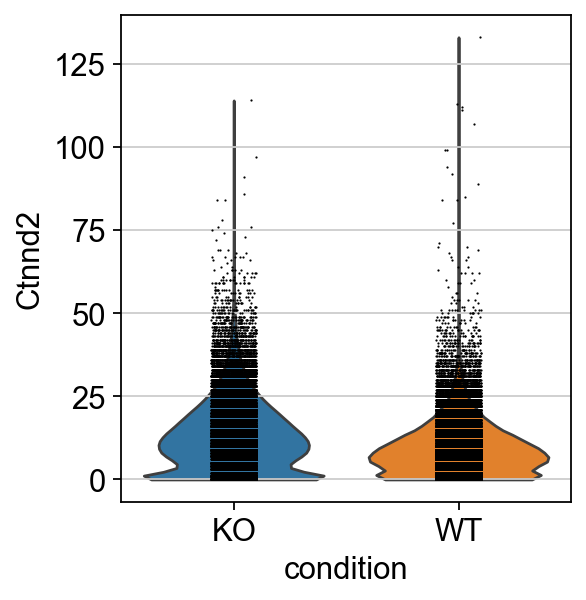

In [29]:
sc.pl.violin(adata, ['Ctnnd2'], groupby='condition', show = True)

In [30]:
adata.write(filtered_raw)

In [44]:
adata.var

,gene_ids,feature_types,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
Xkr4,ENSMUSG00000051951,Gene Expression,False,False,False,87492,6.314653,1.989880,20.247938,692749.0,13.448424
Gm1992,ENSMUSG00000089699,Gene Expression,False,False,False,327,0.003017,0.003013,99.701928,331.0,5.805135
Gm19938,ENSMUSG00000102331,Gene Expression,False,False,False,34776,0.498993,0.404793,68.300442,54742.0,10.910405
Gm37381,ENSMUSG00000102343,Gene Expression,False,False,False,479,0.004457,0.004448,99.563375,489.0,6.194406
Rp1,ENSMUSG00000025900,Gene Expression,False,False,False,1942,0.018878,0.018702,98.229798,2071.0,7.636270
...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000095019,ENSMUSG00000095019,Gene Expression,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000094915,ENSMUSG00000094915,Gene Expression,False,False,False,1,0.000009,0.000009,99.999088,1.0,0.693147
ENSMUSG00000079808,ENSMUSG00000079808,Gene Expression,False,False,False,378,0.003591,0.003585,99.655440,394.0,5.978886
ENSMUSG00000095041,ENSMUSG00000095041,Gene Expression,False,False,False,105720,14.060763,2.712093,3.632469,1542536.0,14.248939


In [50]:
# Doublet detection
sc.pp.scrublet(adata, batch_key="sample")

Running Scrublet
filtered out 8048 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.30
Detected doublet rate = 1.7%
Estimated detectable doublet fraction = 58.1%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 2.9%
filtered out 6903 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata

In [52]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [54]:
adata.var

,gene_ids,feature_types,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
Xkr4,ENSMUSG00000051951,Gene Expression,False,False,False,87492,6.314653,1.989880,20.247938,692749.0,13.448424
Gm1992,ENSMUSG00000089699,Gene Expression,False,False,False,327,0.003017,0.003013,99.701928,331.0,5.805135
Gm19938,ENSMUSG00000102331,Gene Expression,False,False,False,34776,0.498993,0.404793,68.300442,54742.0,10.910405
Gm37381,ENSMUSG00000102343,Gene Expression,False,False,False,479,0.004457,0.004448,99.563375,489.0,6.194406
Rp1,ENSMUSG00000025900,Gene Expression,False,False,False,1942,0.018878,0.018702,98.229798,2071.0,7.636270
...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000095019,ENSMUSG00000095019,Gene Expression,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000094915,ENSMUSG00000094915,Gene Expression,False,False,False,1,0.000009,0.000009,99.999088,1.0,0.693147
ENSMUSG00000079808,ENSMUSG00000079808,Gene Expression,False,False,False,378,0.003591,0.003585,99.655440,394.0,5.978886
ENSMUSG00000095041,ENSMUSG00000095041,Gene Expression,False,False,False,105720,14.060763,2.712093,3.632469,1542536.0,14.248939


In [56]:
#Total-count normalize (library-size correct) the data matrix X to 10,000 reads per cell, so that counts become comparable among cells.
sc.pp.normalize_total(adata, target_sum=1e4)



normalizing counts per cell
    finished (0:00:00)


In [58]:
#Logarithmize the data
sc.pp.log1p(adata)

extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


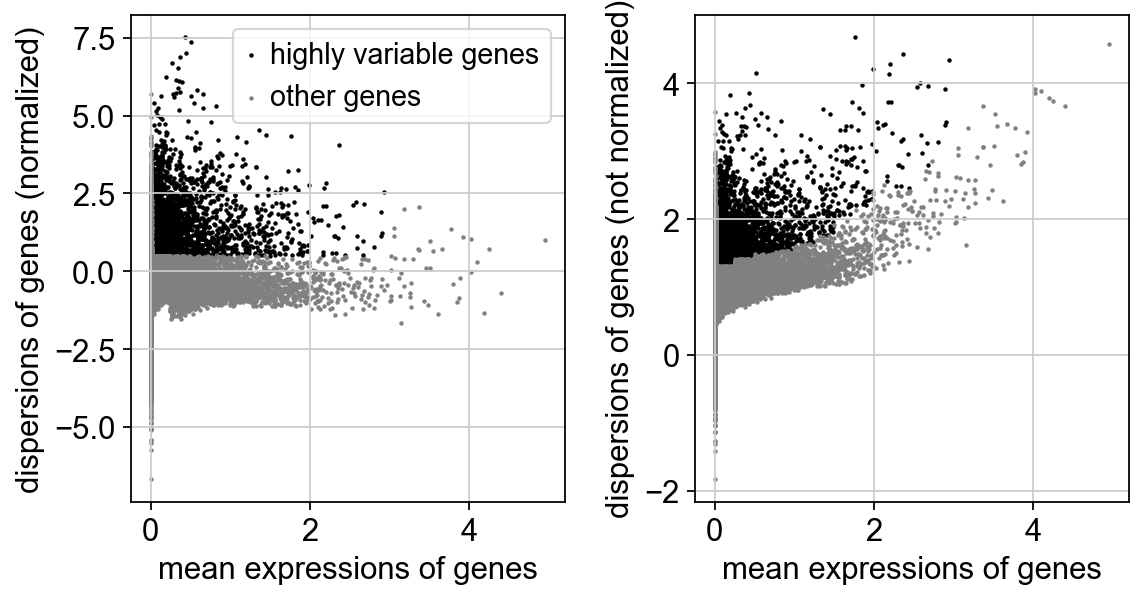

In [60]:
#Identify highly variable genes and plot them
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)

In [61]:
'''
Set the .raw attribute of the AnnData object to the normalized and logarithmized raw gene expression for later use in differential testing and visualizations of gene expression. 
This simply freezes the state of the AnnData object.
Note: You can get back an AnnData of the object in .raw by calling .raw.to_adata().
'''
adata.raw = adata

In [64]:
#Actually do the filtering
adata = adata[:, adata.var.highly_variable]
#Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed. Scale the data to unit variance.
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
#Scale each gene to unit variance. Clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)

regressing out ['total_counts', 'pct_counts_mt']


C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\anndata\_core\anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\anndata\_core\anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\anndata\_core\anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


    sparse input is densified and may lead to high memory use


C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\scanpy\preprocessing\_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\scanpy\preprocessing\_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


    finished (0:00:06)


In [68]:
adata.write(qc_file)

computing PCA
    with n_comps=50
    finished (0:00:10)


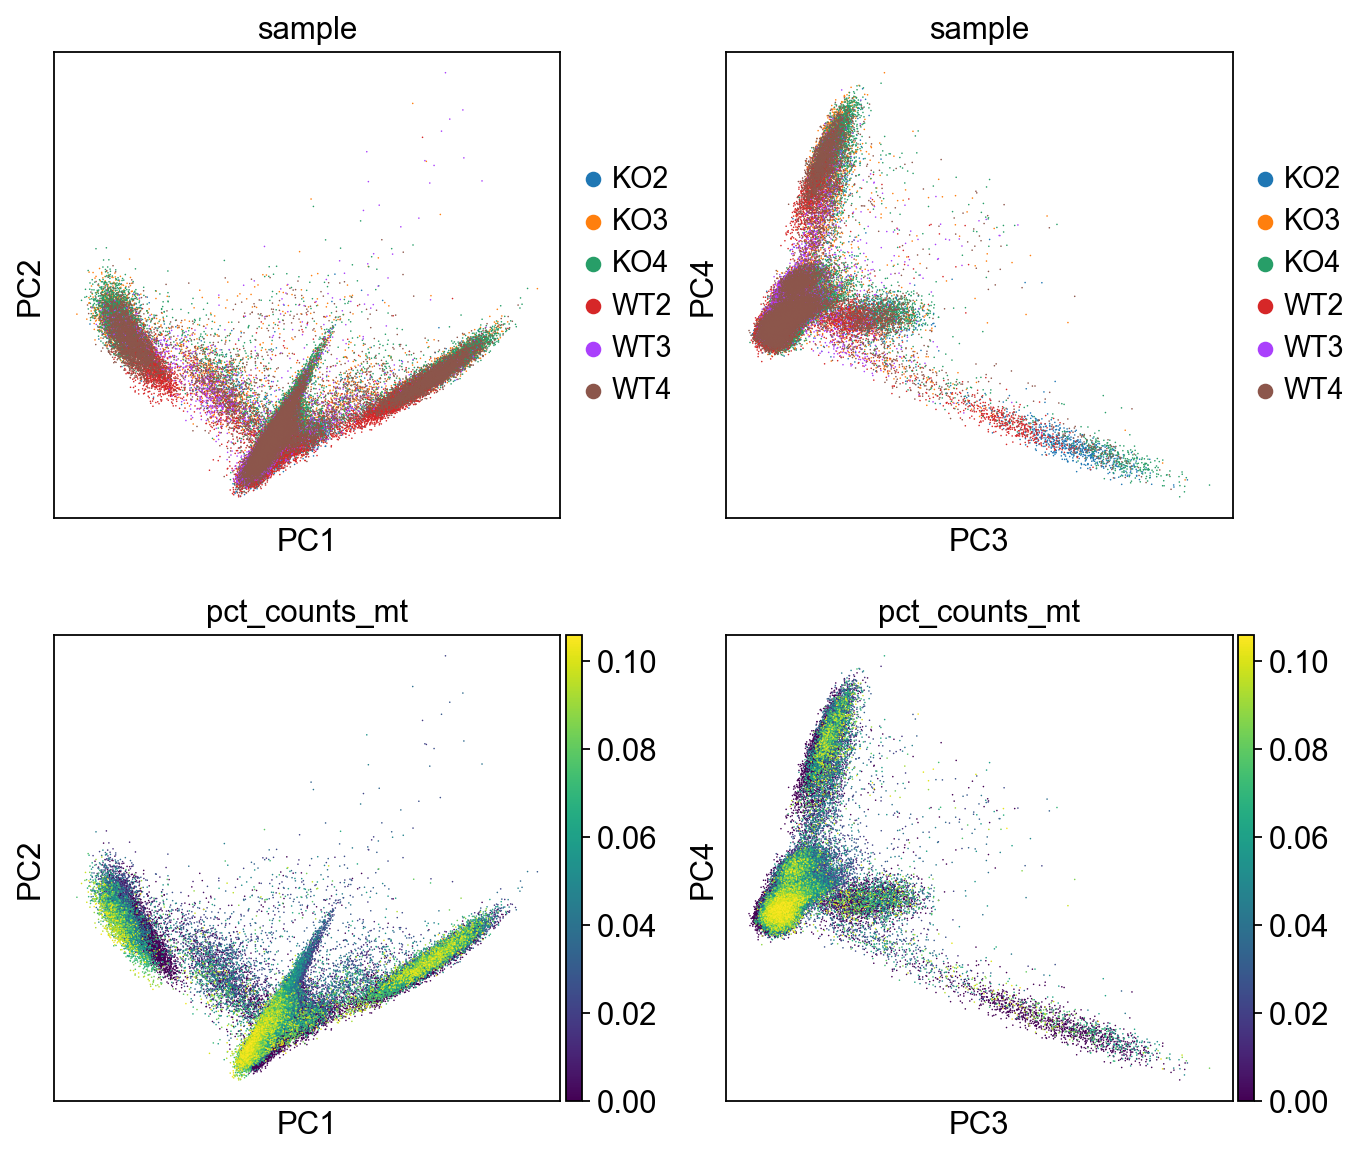

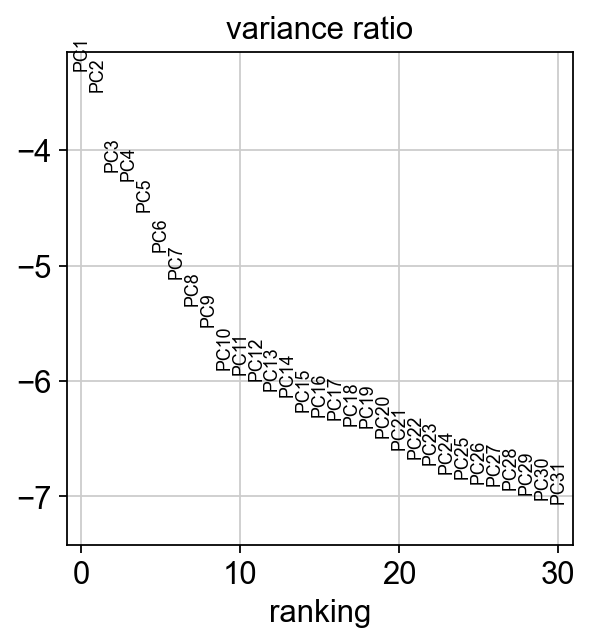

In [70]:
#Reduce the dimensionality of the data by running principal component analysis
sc.tl.pca(adata, svd_solver="arpack")

#make a scatter plot in the PCA coordinates
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

#inspect the contribution of single PCs to the total variance in the data. 
#This gives us information about how many PCs we should consider to compute the neighborhood relations of cells
sc.pl.pca_variance_ratio(adata, log=True)

In [71]:
# Computing the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

#embed in 2D using UMAP
sc.tl.umap(adata)

computing neighbors
    using 'X_pca' with n_pcs = 40


C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:46)


running Leiden clustering


C:\Users\Gabrielle\AppData\Local\Temp\ipykernel_43556\2192905403.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


    finished: found 17 clusters and added
    'leiden_res_0.10', the cluster labels (adata.obs, categorical) (0:00:07)
running Leiden clustering
    finished: found 23 clusters and added
    'leiden_res_0.25', the cluster labels (adata.obs, categorical) (0:00:07)
running Leiden clustering
    finished: found 28 clusters and added
    'leiden_res_0.50', the cluster labels (adata.obs, categorical) (0:00:06)
running Leiden clustering
    finished: found 43 clusters and added
    'leiden_res_1.00', the cluster labels (adata.obs, categorical) (0:00:10)


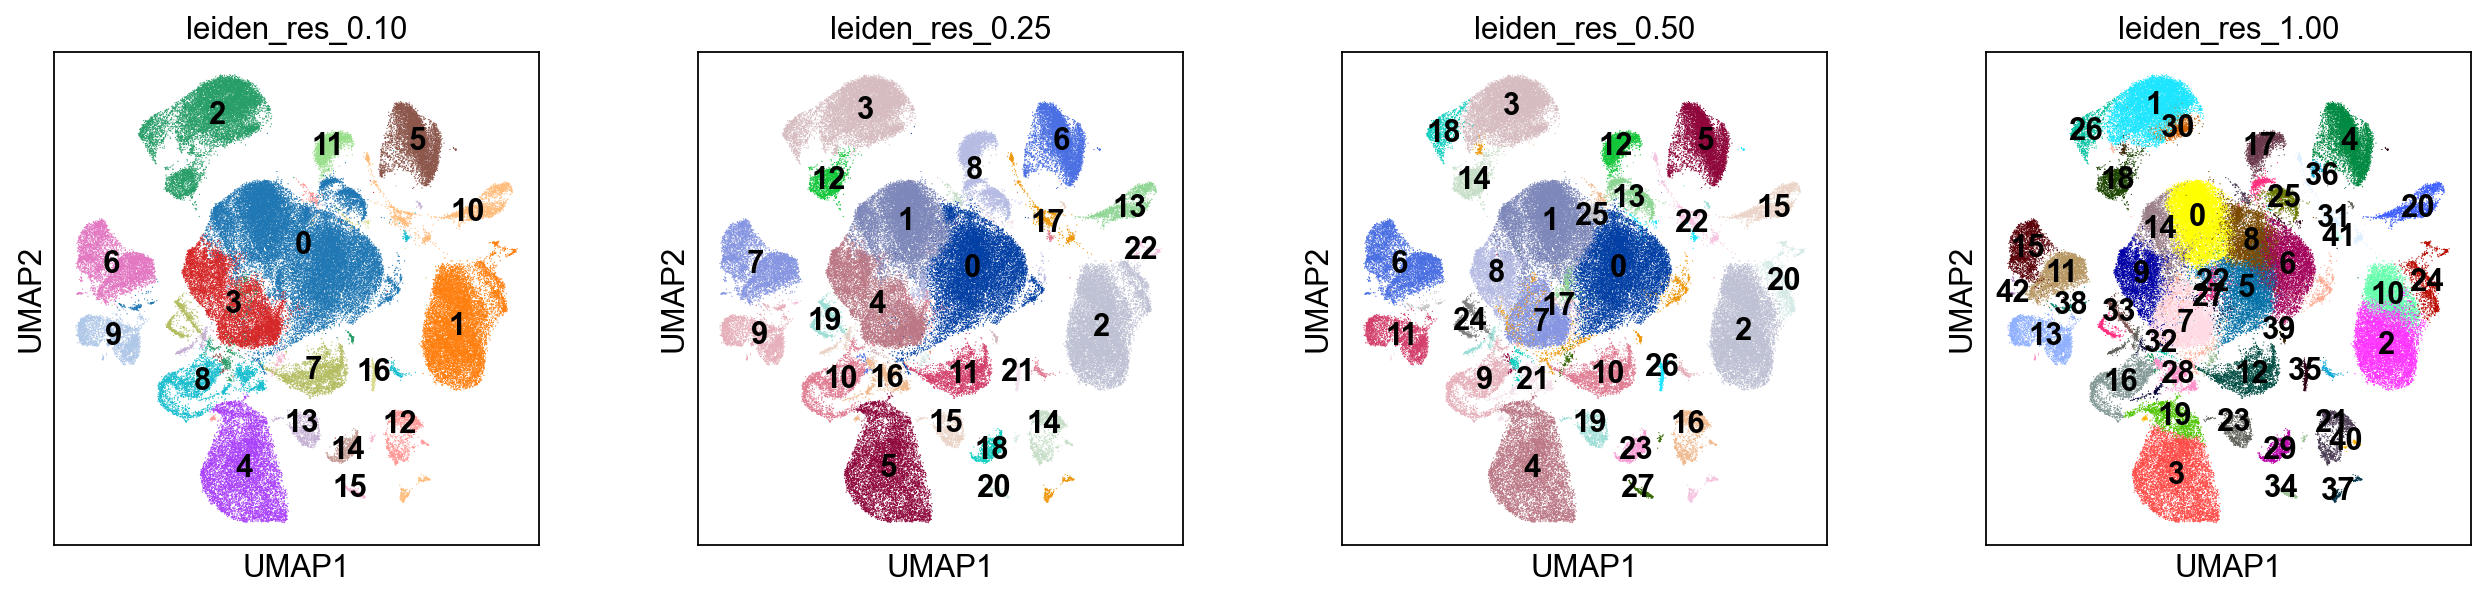

In [73]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
for res in [0.1, 0.25, 0.5, 1.0]:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res:4.2f}", resolution=res
    )

sc.pl.umap(
    adata,
    color=["leiden_res_0.10", "leiden_res_0.25", "leiden_res_0.50", "leiden_res_1.00"],
    legend_loc="on data",
)

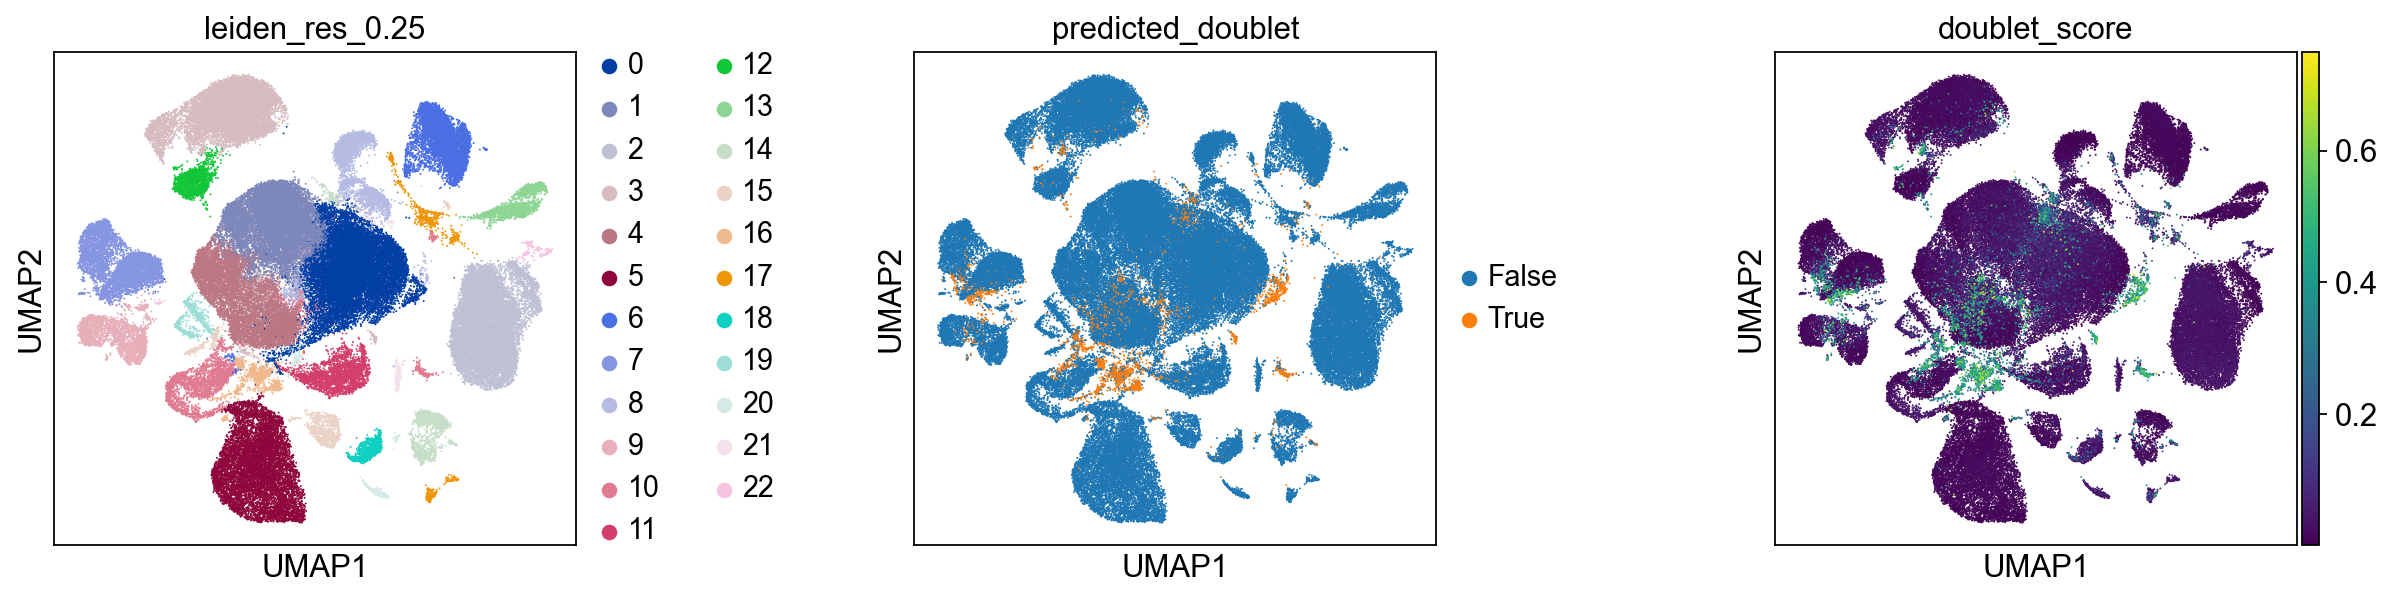

In [74]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.25", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

In [80]:
adata.write(results_file)
adata

AnnData object with n_obs × n_vars = 99966 × 3727
    obs: 'condition', 'sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0.10', 'leiden_res_0.25', 'leiden_res_0.50', 'leiden_res_1.00'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'condition_colors', 'scrublet', 'log1p', 'hvg', 'pca', 'sample_colors', 'neighbors', 'umap', 'leiden_res_0.10', 'leiden_res_0.25', 'leiden_res_0.50', 'leiden_res_1.00', 'leiden_res_0.10_color